 ⛈️ Avión 13 aborta aterrizaje por tormenta (t=623).
 ⛈️ Avión 13 aborta aterrizaje por tormenta (t=625).
 ⛈️ Avión 13 aborta aterrizaje por tormenta (t=627).
 ⛈️ Avión 13 aborta aterrizaje por tormenta (t=629).
 ⛈️ Avión 12 aborta aterrizaje por tormenta (t=616).
 ⛈️ Avión 12 aborta aterrizaje por tormenta (t=618).
 ⛈️ Avión 12 aborta aterrizaje por tormenta (t=620).
 ⛈️ Avión 12 aborta aterrizaje por tormenta (t=622).
 ⛈️ Avión 12 aborta aterrizaje por tormenta (t=624).
 ⛈️ Avión 12 aborta aterrizaje por tormenta (t=626).
 ⛈️ Avión 12 aborta aterrizaje por tormenta (t=628).
 ⛈️ Avión 12 aborta aterrizaje por tormenta (t=630).
 ⛈️ Avión 20 aborta aterrizaje por tormenta (t=608).
 ⛈️ Avión 20 aborta aterrizaje por tormenta (t=610).
 ⛈️ Avión 20 aborta aterrizaje por tormenta (t=612).
 ⛈️ Avión 20 aborta aterrizaje por tormenta (t=614).
 ⛈️ Avión 20 aborta aterrizaje por tormenta (t=616).
 ⛈️ Avión 20 aborta aterrizaje por tormenta (t=618).
 ⛈️ Avión 20 aborta aterrizaje por tormenta (t

,delay_mean,delay_err,div_mean,div_err,landed_mean
λ,,,,,
0.02,1.016416,0.180682,0.000000,0.000000e+00,0.981548
0.10,3.232406,0.108992,0.080404,4.192670e-03,0.894594
0.20,4.247072,0.088887,0.329809,4.820822e-03,0.647899
0.50,0.973609,0.042380,0.698480,1.609273e-03,0.281635
1.00,0.169143,0.000000,0.808333,1.570092e-17,0.162037


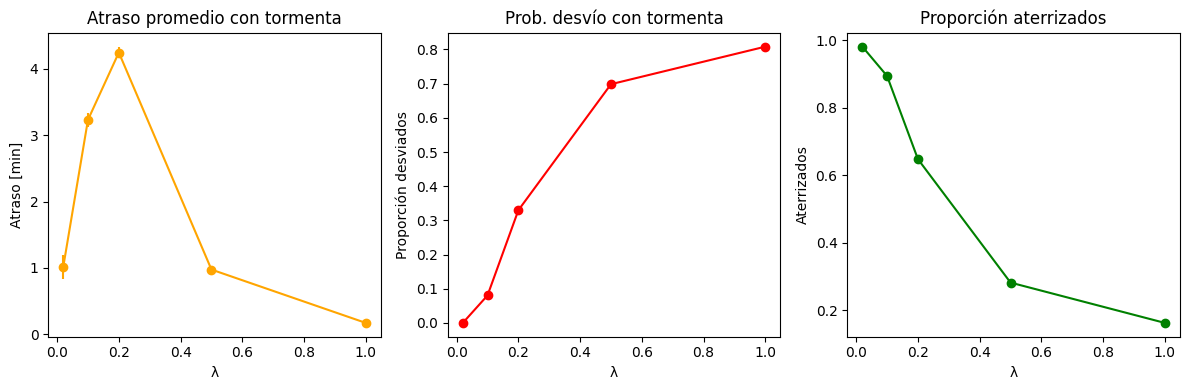

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from main import SimuladorTormenta

# ======================
# Monte Carlo con tormenta
# ======================
def correr_montecarlo_tormenta(lam, n_rep=50, t_inicio=600, duracion=30):
    atrasos, desviados, aterrizados = [], [], []
    for rep in range(n_rep):
        sim = SimuladorTormenta(seed=rep, t_inicio=t_inicio, duracion=duracion)
        sim.simular_dia(lam)
        avs = list(sim.aviones.values())

        # atrasos
        atrasos_rep = [a.retraso for a in avs if a.estado == "ATERRIZADO"]
        atrasos.append(np.mean(atrasos_rep) if atrasos_rep else 0)

        # proporción desviados
        desviados.append(sum(1 for a in avs if a.estado == "DESVIADO") / max(1, len(avs)))

        # proporción aterrizados
        aterrizados.append(sum(1 for a in avs if a.estado == "ATERRIZADO") / max(1, len(avs)))

    return {
        "delay_mean": np.mean(atrasos), "delay_err": np.std(atrasos)/np.sqrt(n_rep),
        "div_mean": np.mean(desviados), "div_err": np.std(desviados)/np.sqrt(n_rep),
        "landed_mean": np.mean(aterrizados)
    }

# ======================
# Experimentos
# ======================
LAMBDAS = [0.02, 0.1, 0.2, 0.5, 1.0]
resultados = {lam: correr_montecarlo_tormenta(lam, n_rep=50) for lam in LAMBDAS}

df = pd.DataFrame(resultados).T
df.index.name = "λ"
display(df)

# ======================
# Gráficos
# ======================
plt.figure(figsize=(12,4))

# atrasos
plt.subplot(1,3,1)
plt.errorbar(df.index, df["delay_mean"], yerr=df["delay_err"], fmt="-o", color="orange")
plt.title("Atraso promedio con tormenta")
plt.xlabel("λ"); plt.ylabel("Atraso [min]")

# desviados
plt.subplot(1,3,2)
plt.errorbar(df.index, df["div_mean"], yerr=df["div_err"], fmt="-o", color="red")
plt.title("Prob. desvío con tormenta")
plt.xlabel("λ"); plt.ylabel("Proporción desviados")

# aterrizados
plt.subplot(1,3,3)
plt.plot(df.index, df["landed_mean"], "-o", color="green")
plt.title("Proporción aterrizados")
plt.xlabel("λ"); plt.ylabel("Aterrizados")

plt.tight_layout()
plt.show()
